## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

## Loading Dataset

In [2]:
df = pd.read_csv(r'data.csv')
df

,company,ticker,sector,is_ai_company,ipo_status,expected_or_listing_date,ipo_valuation_usd_b,last_private_valuation_usd_b,amount_raised_usd_b,latest_annual_revenue_or_arr_usd_b,revenue_type,year_founded,headquarters_country,lead_investor_or_backer,valuation_to_revenue_multiple,years_to_ipo,notes
0,SpaceX,SPCX,Space / Aerospace,No,Listed,2026-06-12,1750.0,400.0,75.0,15.50,Revenue,2002,United States,Founders Fund,112.9,24,"Largest IPO ever, surpassing Saudi Aramco"
1,OpenAI,OPAI,AI / Foundation Models,Yes,Expected,2026-Q4,730.0,500.0,40.0,13.00,ARR,2015,United States,Microsoft,56.2,11,Most-anticipated AI IPO; valuation debate
2,Anthropic,ANTH,AI / Foundation Models,Yes,Filed,2026-Q4,900.0,380.0,50.0,9.00,ARR,2021,United States,Google,100.0,5,Talks to raise $50B at $900B valuation
3,Databricks,DBRX,Data / Analytics / AI,Yes,Filed,2026-Q3,134.0,134.0,12.0,3.70,ARR,2013,United States,Andreessen Horowitz,36.2,13,Data + AI platform; high ARR multiple
4,Stripe,STRP,Fintech / Payments,No,Expected,2026-Q4,91.5,91.5,4.0,5.10,Revenue,2010,United States,Sequoia Capital,17.9,16,Long-awaited fintech debut
5,Canva,CNVA,Design / SaaS,No,Filed,2026-Q3,49.0,49.0,3.0,3.00,ARR,2013,Australia,Blackbird Ventures,16.3,13,Profitable design unicorn
6,Klarna,KLAR,Fintech / BNPL,No,Listed,2026-04-15,20.0,6.7,1.4,2.80,Revenue,2005,Sweden,Sequoia Capital,7.1,21,Rebounded from 2022 valuation cut
7,Discord,DCRD,Social / Communication,No,Filed,2026-Q4,17.0,15.0,1.2,0.90,Revenue,2015,United States,Greylock Partners,18.9,11,Confidential filing
8,Cohere,CHRE,AI / Foundation Models,Yes,Expected,2026-Q4,12.0,7.0,2.0,0.10,ARR,2019,Canada,Inovia Capital,120.0,7,Enterprise AI focus
9,Chime,CHYM,Fintech / Neobank,No,Listed,2026-03-20,13.0,25.0,0.9,1.70,Revenue,2012,United States,DST Global,7.6,14,Down-round IPO from peak


## EDA

In [3]:
df.head()

,company,ticker,sector,is_ai_company,ipo_status,expected_or_listing_date,ipo_valuation_usd_b,last_private_valuation_usd_b,amount_raised_usd_b,latest_annual_revenue_or_arr_usd_b,revenue_type,year_founded,headquarters_country,lead_investor_or_backer,valuation_to_revenue_multiple,years_to_ipo,notes
0,SpaceX,SPCX,Space / Aerospace,No,Listed,2026-06-12,1750.0,400.0,75.0,15.5,Revenue,2002,United States,Founders Fund,112.9,24,"Largest IPO ever, surpassing Saudi Aramco"
1,OpenAI,OPAI,AI / Foundation Models,Yes,Expected,2026-Q4,730.0,500.0,40.0,13.0,ARR,2015,United States,Microsoft,56.2,11,Most-anticipated AI IPO; valuation debate
2,Anthropic,ANTH,AI / Foundation Models,Yes,Filed,2026-Q4,900.0,380.0,50.0,9.0,ARR,2021,United States,Google,100.0,5,Talks to raise $50B at $900B valuation
3,Databricks,DBRX,Data / Analytics / AI,Yes,Filed,2026-Q3,134.0,134.0,12.0,3.7,ARR,2013,United States,Andreessen Horowitz,36.2,13,Data + AI platform; high ARR multiple
4,Stripe,STRP,Fintech / Payments,No,Expected,2026-Q4,91.5,91.5,4.0,5.1,Revenue,2010,United States,Sequoia Capital,17.9,16,Long-awaited fintech debut


In [4]:
df.shape

(18, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 17 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   company                             18 non-null     object 
 1   ticker                              18 non-null     object 
 2   sector                              18 non-null     object 
 3   is_ai_company                       18 non-null     object 
 4   ipo_status                          18 non-null     object 
 5   expected_or_listing_date            18 non-null     object 
 6   ipo_valuation_usd_b                 18 non-null     float64
 7   last_private_valuation_usd_b        18 non-null     float64
 8   amount_raised_usd_b                 18 non-null     float64
 9   latest_annual_revenue_or_arr_usd_b  18 non-null     float64
 10  revenue_type                        18 non-null     object 
 11  year_founded                        18 non-null

In [6]:
df.describe()

,ipo_valuation_usd_b,last_private_valuation_usd_b,amount_raised_usd_b,latest_annual_revenue_or_arr_usd_b,year_founded,valuation_to_revenue_multiple,years_to_ipo
count,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000
mean,215.838889,97.444444,11.205556,3.814444,2012.500000,37.916667,13.500000
std,460.383320,156.716695,21.251366,4.520569,7.422145,39.995415,7.422145
min,2.200000,1.500000,0.300000,0.100000,1991.000000,5.100000,3.000000
25%,13.250000,8.600000,1.000000,0.660000,2010.500000,9.825000,10.000000
50%,24.500000,27.000000,2.000000,2.250000,2014.000000,18.400000,12.000000
75%,84.875000,80.875000,4.750000,4.825000,2016.000000,51.200000,15.500000
max,1750.000000,500.000000,75.000000,15.500000,2023.000000,120.000000,35.000000


## Missing Values

In [7]:
df.isnull().sum()

company                               0
ticker                                0
sector                                0
is_ai_company                         0
ipo_status                            0
expected_or_listing_date              0
ipo_valuation_usd_b                   0
last_private_valuation_usd_b          0
amount_raised_usd_b                   0
latest_annual_revenue_or_arr_usd_b    0
revenue_type                          0
year_founded                          0
headquarters_country                  0
lead_investor_or_backer               0
valuation_to_revenue_multiple         0
years_to_ipo                          0
notes                                 0
dtype: int64

## Data Cleaning

In [ ]:
df['expected_or_listing_date'] = df['expected_or_listing_date'].fillna('Unknown')
df['lead_investor_or_backer'] = df['lead_investor_or_backer'].fillna('Unknown')
df['notes'] = df['notes'].fillna('')

# Convert date columns
df['expected_or_listing_date'] = pd.to_datetime(df['expected_or_listing_date'], errors='coerce')
print("After cleaning records:", len(df))
df.head()

After cleaning records: 18


,company,ticker,sector,is_ai_company,ipo_status,expected_or_listing_date,ipo_valuation_usd_b,last_private_valuation_usd_b,amount_raised_usd_b,latest_annual_revenue_or_arr_usd_b,revenue_type,year_founded,headquarters_country,lead_investor_or_backer,valuation_to_revenue_multiple,years_to_ipo,notes
0,SpaceX,SPCX,Space / Aerospace,No,Listed,2026-06-12,1750.0,400.0,75.0,15.5,Revenue,2002,United States,Founders Fund,112.9,24,"Largest IPO ever, surpassing Saudi Aramco"
1,OpenAI,OPAI,AI / Foundation Models,Yes,Expected,NaT,730.0,500.0,40.0,13.0,ARR,2015,United States,Microsoft,56.2,11,Most-anticipated AI IPO; valuation debate
2,Anthropic,ANTH,AI / Foundation Models,Yes,Filed,NaT,900.0,380.0,50.0,9.0,ARR,2021,United States,Google,100.0,5,Talks to raise $50B at $900B valuation
3,Databricks,DBRX,Data / Analytics / AI,Yes,Filed,NaT,134.0,134.0,12.0,3.7,ARR,2013,United States,Andreessen Horowitz,36.2,13,Data + AI platform; high ARR multiple
4,Stripe,STRP,Fintech / Payments,No,Expected,NaT,91.5,91.5,4.0,5.1,Revenue,2010,United States,Sequoia Capital,17.9,16,Long-awaited fintech debut


## Company Distribution by Sector

Sector Distribution:
sector
AI / Foundation Models       4
Fintech / Neobank            2
Data / Analytics / AI        1
Fintech / Payments           1
Design / SaaS                1
Space / Aerospace            1
Fintech / BNPL               1
Social / Communication       1
Health / Fitness / Social    1
Mobility / Transport         1
Fintech / Infrastructure     1
AI / Data Labeling           1
Gaming / Software            1
HR Tech / SaaS               1
Name: count, dtype: int64


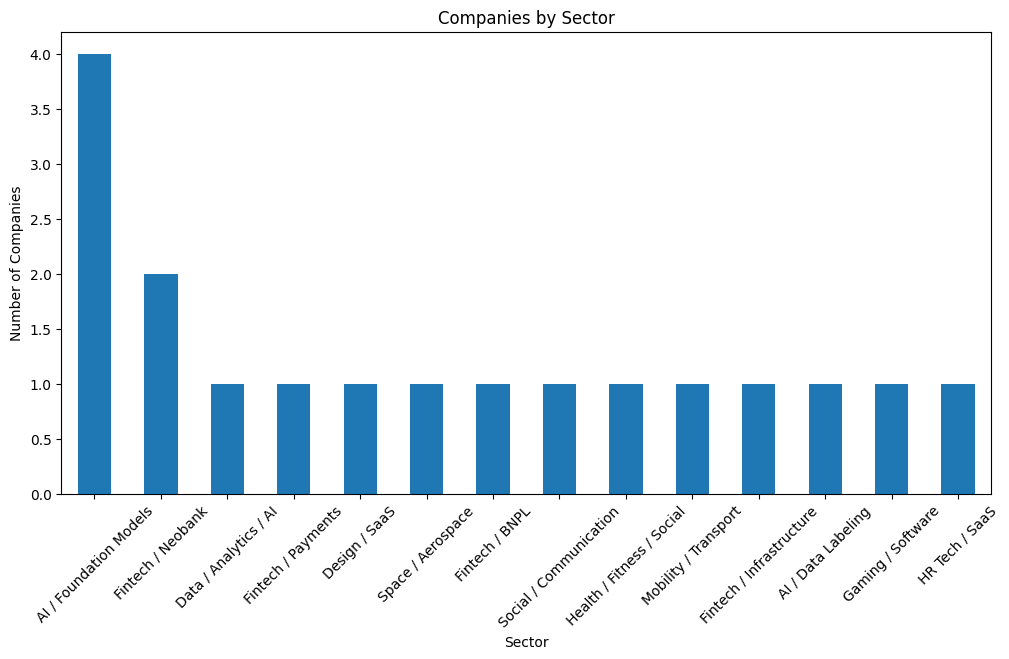

In [9]:
sector_counts = df['sector'].value_counts()
print("Sector Distribution:")
print(sector_counts)

plt.figure(figsize=(12, 6))
sector_counts.plot(kind='bar')
plt.xlabel('Sector')
plt.ylabel('Number of Companies')
plt.title('Companies by Sector')
plt.xticks(rotation=45)
plt.show()

## AI vs Non-AI Companies

AI vs Non-AI Companies:
is_ai_company
No     12
Yes     6
Name: count, dtype: int64


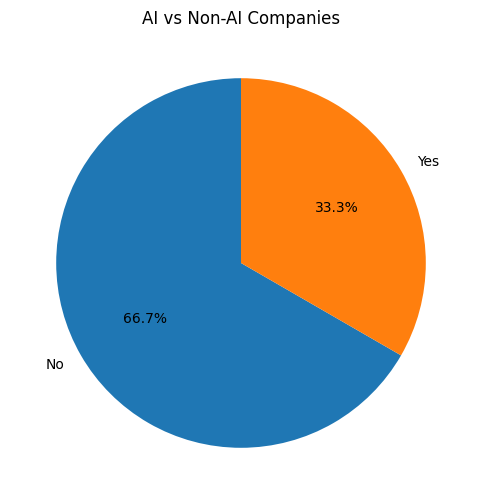

In [10]:
ai_counts = df['is_ai_company'].value_counts()
print("AI vs Non-AI Companies:")
print(ai_counts)

plt.figure(figsize=(8, 6))
ai_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('AI vs Non-AI Companies')
plt.ylabel('')
plt.show()

##  IPO Status Distribution

IPO Status Distribution:
ipo_status
Expected    8
Filed       7
Listed      3
Name: count, dtype: int64


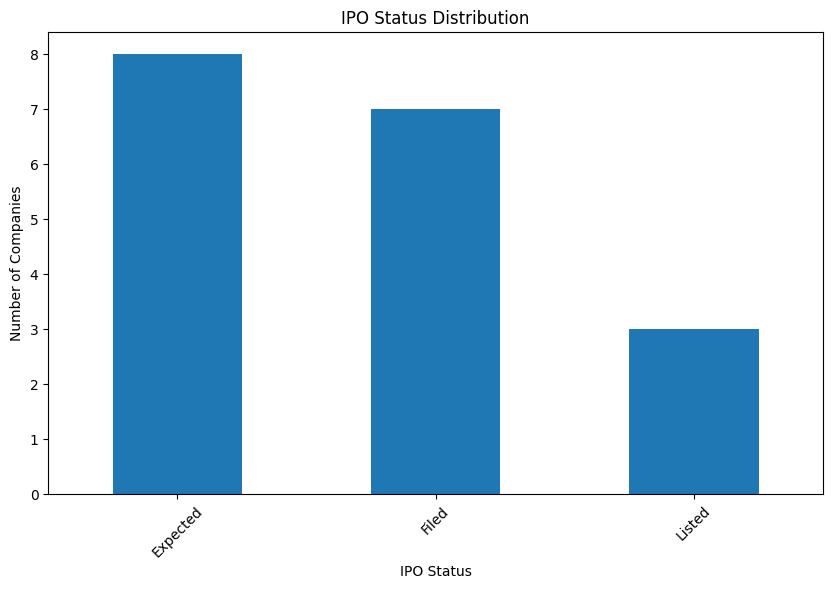

In [11]:
status_counts = df['ipo_status'].value_counts()
print("IPO Status Distribution:")
print(status_counts)

plt.figure(figsize=(10, 6))
status_counts.plot(kind='bar')
plt.xlabel('IPO Status')
plt.ylabel('Number of Companies')
plt.title('IPO Status Distribution')
plt.xticks(rotation=45)
plt.show()

## Valuation Analysis

In [12]:
print("Valuation Statistics:")
print(f"Average IPO Valuation: ${df['ipo_valuation_usd_b'].mean():.2f}B")
print(f"Max IPO Valuation: ${df['ipo_valuation_usd_b'].max():.2f}B")
print(f"Min IPO Valuation: ${df['ipo_valuation_usd_b'].min():.2f}B")
print(f"Total IPO Valuation: ${df['ipo_valuation_usd_b'].sum():.2f}B")

print(f"\nAverage Private Valuation: ${df['last_private_valuation_usd_b'].mean():.2f}B")
print(f"Total Private Valuation: ${df['last_private_valuation_usd_b'].sum():.2f}B")

Valuation Statistics:
Average IPO Valuation: $215.84B
Max IPO Valuation: $1750.00B
Min IPO Valuation: $2.20B
Total IPO Valuation: $3885.10B

Average Private Valuation: $97.44B
Total Private Valuation: $1754.00B


##  Valuation Comparison

In [ ]:
ai_avg = df.groupby('is_ai_company')['ipo_valuation_usd_b'].mean()
print("Average IPO Valuation by Type:")
print(ai_avg)

Average IPO Valuation by Type:
is_ai_company
No     172.175000
Yes    303.166667
Name: ipo_valuation_usd_b, dtype: float64


## Valuation to Revenue Multiple Analysis

In [ ]:
print("Valuation to Revenue Multiple Statistics:")
print(f"Mean: {df['valuation_to_revenue_multiple'].mean():.2f}")
print(f"Median: {df['valuation_to_revenue_multiple'].median():.2f}")
print(f"Max: {df['valuation_to_revenue_multiple'].max():.2f}")
print(f"Min: {df['valuation_to_revenue_multiple'].min():.2f}")


print("Top 5 Companies by Valuation/Revenue Multiple:")
print(df.nlargest(5, 'valuation_to_revenue_multiple')[['company', 'sector', 'valuation_to_revenue_multiple']])

Valuation to Revenue Multiple Statistics:
Mean: 37.92
Median: 18.40
Max: 120.00
Min: 5.10

Top 5 Companies by Valuation/Revenue Multiple:
       company                  sector  valuation_to_revenue_multiple
8       Cohere  AI / Foundation Models                          120.0
0       SpaceX       Space / Aerospace                          112.9
2    Anthropic  AI / Foundation Models                          100.0
14  Mistral AI  AI / Foundation Models                           93.3
1       OpenAI  AI / Foundation Models                           56.2


## AI vs Non-AI Multiples

In [31]:
ai_multiples = df.groupby('is_ai_company')['valuation_to_revenue_multiple'].mean()
print("Average Multiples:")
print(ai_multiples)

Average Multiples:
is_ai_company
No     21.341667
Yes    71.066667
Name: valuation_to_revenue_multiple, dtype: float64


## Years to IPO Analysis

In [16]:
print("Years to IPO Statistics:")
print(f"Mean: {df['years_to_ipo'].mean():.2f} years")
print(f"Median: {df['years_to_ipo'].median():.2f} years")
print(f"Max: {df['years_to_ipo'].max():.2f} years")
print(f"Min: {df['years_to_ipo'].min():.2f} years")

# Sector-wise years to IPO
print("\nSector-wise Average Years to IPO:")
print(df.groupby('sector')['years_to_ipo'].mean().sort_values())

Years to IPO Statistics:
Mean: 13.50 years
Median: 12.00 years
Max: 35.00 years
Min: 3.00 years

Sector-wise Average Years to IPO:
sector
AI / Foundation Models        6.5
Mobility / Transport          9.0
HR Tech / SaaS               10.0
AI / Data Labeling           10.0
Social / Communication       11.0
Fintech / Neobank            12.5
Design / SaaS                13.0
Data / Analytics / AI        13.0
Fintech / Infrastructure     13.0
Fintech / Payments           16.0
Health / Fitness / Social    17.0
Fintech / BNPL               21.0
Space / Aerospace            24.0
Gaming / Software            35.0
Name: years_to_ipo, dtype: float64


## Correlation Heatmap

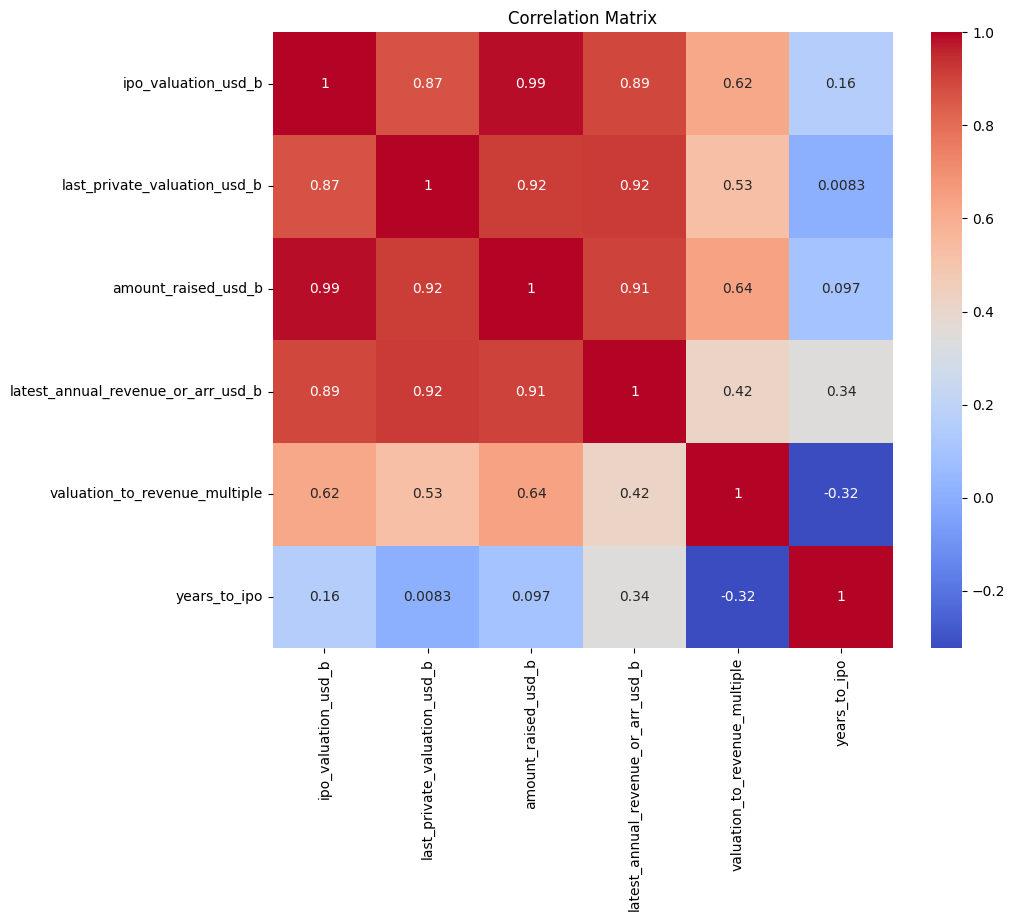

In [17]:
numeric_cols = ['ipo_valuation_usd_b', 'last_private_valuation_usd_b', 
                'amount_raised_usd_b', 'latest_annual_revenue_or_arr_usd_b',
                'valuation_to_revenue_multiple', 'years_to_ipo']

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Encode Categorical Columns

In [19]:
le = LabelEncoder()
df['sector_encoded'] = le.fit_transform(df['sector'])
df['ipo_status_encoded'] = le.fit_transform(df['ipo_status'])
df['is_ai_encoded'] = df['is_ai_company'].map({'No': 0, 'Yes': 1})
df['headquarters_encoded'] = le.fit_transform(df['headquarters_country'])

df[['company', 'sector', 'sector_encoded', 'is_ai_company', 'is_ai_encoded']].head()

,company,sector,sector_encoded,is_ai_company,is_ai_encoded
0,SpaceX,Space / Aerospace,13,No,0
1,OpenAI,AI / Foundation Models,1,Yes,1
2,Anthropic,AI / Foundation Models,1,Yes,1
3,Databricks,Data / Analytics / AI,2,Yes,1
4,Stripe,Fintech / Payments,7,No,0


## Linear Regression - Predict IPO Valuation

In [20]:
X = df[['last_private_valuation_usd_b', 'amount_raised_usd_b', 
        'latest_annual_revenue_or_arr_usd_b', 'years_to_ipo']]
y = df['ipo_valuation_usd_b']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R² Score:", r2_score(y_test, pred))

print("\nFeature Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")

MSE: 35393.83630164444
RMSE: 188.13249666563308
R² Score: 0.9286333565811452

Feature Coefficients:
last_private_valuation_usd_b: -0.2600
amount_raised_usd_b: 19.2955
latest_annual_revenue_or_arr_usd_b: 3.0492
years_to_ipo: -0.1843


## Random Forest Regression - Predict IPO Valuation

In [21]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R² Score:", r2_score(y_test, pred))

print("\nFeature Importance:")
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
print(importance)

MSE: 391953.1947465
RMSE: 626.0616541096412
R² Score: 0.2096820574079794

Feature Importance:
                              Feature  Importance
1                 amount_raised_usd_b    0.406970
0        last_private_valuation_usd_b    0.319626
2  latest_annual_revenue_or_arr_usd_b    0.161891
3                        years_to_ipo    0.111513


## Classification - AI Company Prediction

In [22]:
X = df[['ipo_valuation_usd_b', 'valuation_to_revenue_multiple', 'years_to_ipo']]
y = df['is_ai_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("\nClassification Report:")
print(classification_report(y_test, pred, target_names=['Non-AI', 'AI']))
print("\nFeature Importance:")
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
print(importance)

Accuracy: 0.75

Classification Report:
              precision    recall  f1-score   support

      Non-AI       1.00      0.50      0.67         2
          AI       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4


Feature Importance:
                         Feature  Importance
1  valuation_to_revenue_multiple    0.507337
0            ipo_valuation_usd_b    0.263118
2                   years_to_ipo    0.229545


## KMeans Clustering

In [23]:
X_cluster = df[['ipo_valuation_usd_b', 'valuation_to_revenue_multiple', 'years_to_ipo']]
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

print(df[['company', 'sector', 'ipo_valuation_usd_b', 'Cluster']].head())
print("\nCluster Distribution:")
print(df['Cluster'].value_counts())

      company                  sector  ipo_valuation_usd_b  Cluster
0      SpaceX       Space / Aerospace               1750.0        2
1      OpenAI  AI / Foundation Models                730.0        1
2   Anthropic  AI / Foundation Models                900.0        1
3  Databricks   Data / Analytics / AI                134.0        0
4      Stripe      Fintech / Payments                 91.5        0

Cluster Distribution:
Cluster
0    13
1     4
2     1
Name: count, dtype: int64


## Cluster Visualization

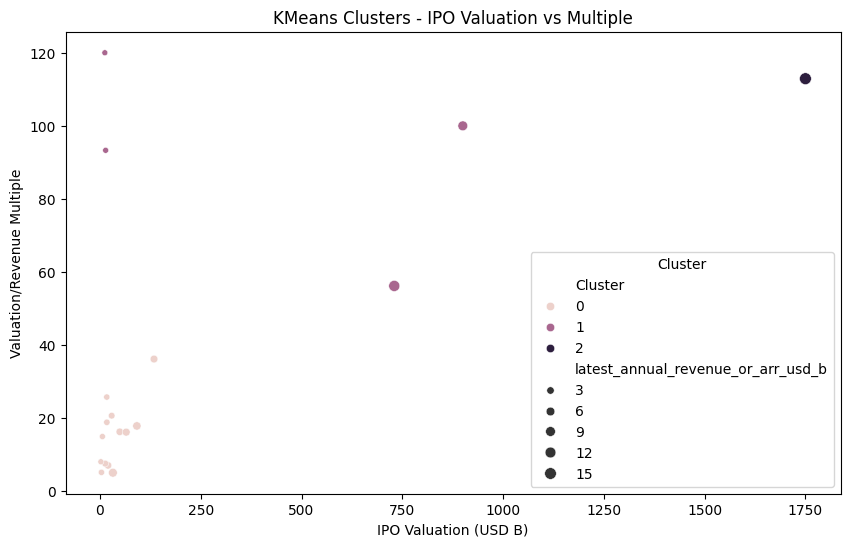


Cluster Centers:
   IPO Valuation    Multiple  Years to IPO
0      36.853846   15.392308     14.846154
1     414.000000   92.375000      6.500000
2    1750.000000  112.900000     24.000000


In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['ipo_valuation_usd_b'], y=df['valuation_to_revenue_multiple'], 
                hue=df['Cluster'], size=df['latest_annual_revenue_or_arr_usd_b'])
plt.xlabel('IPO Valuation (USD B)')
plt.ylabel('Valuation/Revenue Multiple')
plt.title('KMeans Clusters - IPO Valuation vs Multiple')
plt.legend(title='Cluster')
plt.show()

print("\nCluster Centers:")
print(pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), 
                   columns=['IPO Valuation', 'Multiple', 'Years to IPO']))

## Business Insights

In [29]:
print("Top 5 Highest IPO Valuations:")
print(df.nlargest(5, 'ipo_valuation_usd_b')[['company', 'sector', 'ipo_valuation_usd_b']])

print("Top 5 Highest Revenue Companies:")
print(df.nlargest(5, 'latest_annual_revenue_or_arr_usd_b')[['company', 'sector', 'latest_annual_revenue_or_arr_usd_b']])

# AI vs Non-AI summary
ai_df = df[df['is_ai_company'] == True]
non_ai_df = df[df['is_ai_company'] == False]

print(f"AI Companies:")
print(f"Count: {len(ai_df)}")
print(f"Total Valuation: ${ai_df['ipo_valuation_usd_b'].sum():.2f}B")
print(f"Avg Multiple: {ai_df['valuation_to_revenue_multiple'].mean():.2f}x")

print(f"Non-AI Companies:")
print(f"Count: {len(non_ai_df)}")
print(f"Total Valuation: ${non_ai_df['ipo_valuation_usd_b'].sum():.2f}B")
print(f"Avg Multiple: {non_ai_df['valuation_to_revenue_multiple'].mean():.2f}x")

# Sector with highest average valuation
print(f"Sector with Highest Average Valuation:")
print(df.groupby('sector')['ipo_valuation_usd_b'].mean().sort_values(ascending=False).head(3))

# Up-round vs Down-round
df['valuation_change'] = df['ipo_valuation_usd_b'] - df['last_private_valuation_usd_b']
up_round = len(df[df['valuation_change'] > 0])
down_round = len(df[df['valuation_change'] < 0])
same_round = len(df[df['valuation_change'] == 0])

print(f"Up-Round IPOs: {up_round}")
print(f"Down-Round IPOs: {down_round}")
print(f"Same Valuation: {same_round}")

Top 5 Highest IPO Valuations:
      company                  sector  ipo_valuation_usd_b
0      SpaceX       Space / Aerospace               1750.0
2   Anthropic  AI / Foundation Models                900.0
1      OpenAI  AI / Foundation Models                730.0
3  Databricks   Data / Analytics / AI                134.0
4      Stripe      Fintech / Payments                 91.5
Top 5 Highest Revenue Companies:
       company                  sector  latest_annual_revenue_or_arr_usd_b
0       SpaceX       Space / Aerospace                                15.5
1       OpenAI  AI / Foundation Models                                13.0
2    Anthropic  AI / Foundation Models                                 9.0
16  Epic Games       Gaming / Software                                 6.3
4       Stripe      Fintech / Payments                                 5.1
AI Companies:
Count: 0
Total Valuation: $0.00B
Avg Multiple: nanx
Non-AI Companies:
Count: 0
Total Valuation: $0.00B
Avg Multiple: na

## Bubble Chart - Valuation vs Revenue

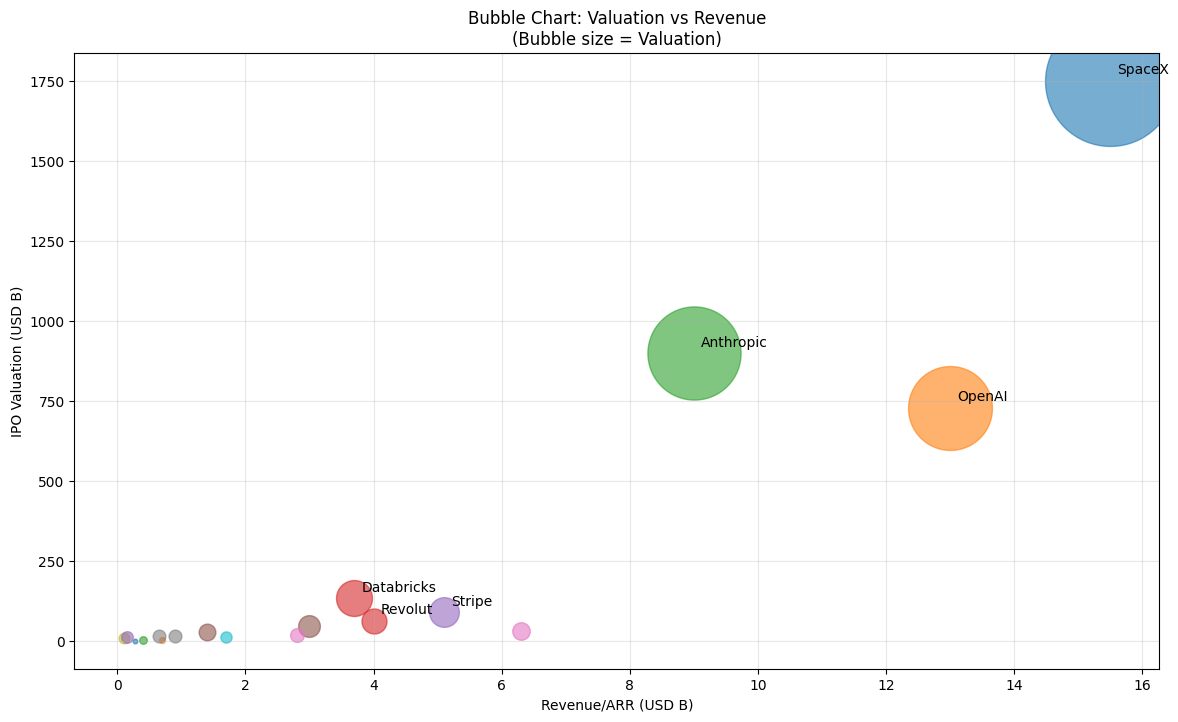

In [ ]:
plt.figure(figsize=(14, 8))

for company in df['company']:
    row = df[df['company'] == company]
    plt.scatter(row['latest_annual_revenue_or_arr_usd_b'], 
                row['ipo_valuation_usd_b'],
                s=row['ipo_valuation_usd_b'] * 5,
                label=company,
                alpha=0.6)

plt.xlabel('Revenue/ARR (USD B)')
plt.ylabel('IPO Valuation (USD B)')
plt.title('Bubble Chart: Valuation vs Revenue\n(Bubble size = Valuation)')

# Adding labels for top companies
for _, row in df.iterrows():
    if row['ipo_valuation_usd_b'] > 50:
        plt.annotate(row['company'], 
                     (row['latest_annual_revenue_or_arr_usd_b'], row['ipo_valuation_usd_b']),
                     xytext=(5, 5), textcoords='offset points')

plt.grid(True, alpha=0.3)
plt.show()

## Sector-wise Valuation Summary

In [27]:
sector_summary = df.groupby('sector').agg({
    'ipo_valuation_usd_b': ['sum', 'mean', 'count'],
    'valuation_to_revenue_multiple': 'mean'
}).round(2)

sector_summary.columns = ['Total Valuation (B)', 'Avg Valuation (B)', 'Count', 'Avg Multiple']
print("Sector-wise Summary:")
print(sector_summary.sort_values('Total Valuation (B)', ascending=False))

Sector-wise Summary:
                           Total Valuation (B)  Avg Valuation (B)  Count  \
sector                                                                     
Space / Aerospace                       1750.0             1750.0      1   
AI / Foundation Models                  1656.0              414.0      4   
Data / Analytics / AI                    134.0              134.0      1   
Fintech / Payments                        91.5               91.5      1   
Fintech / Neobank                         78.0               39.0      2   
Design / SaaS                             49.0               49.0      1   
Gaming / Software                         32.0               32.0      1   
AI / Data Labeling                        29.0               29.0      1   
Fintech / BNPL                            20.0               20.0      1   
Social / Communication                    17.0               17.0      1   
HR Tech / SaaS                            16.8               16.8  